<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/numerical-programming-hw-04/breast_cancer_distance_metrics_homework_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Тема 4
## Метрики відстані, матриці відстаней та кореляція

У роботі використано набір даних **Breast Cancer Wisconsin** з бібліотеки `sklearn`.

Мета: дослідити структуру даних, стандартизувати ознаки, побудувати візуалізації, обчислити матриці відстаней для різних метрик та зробити висновки щодо їх використання.

## 1. Імпорт бібліотек та завантаження даних

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

sns.set_theme(style="whitegrid")

In [16]:
data = load_breast_cancer()

print(data.DESCR[:2500])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## 2. Створення DataFrame

In [17]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df["target_name"] = df["target"].map({0: "malignant", 1: "benign"})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 3. Інформація про дані

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## 4. Описові статистики

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 5. Стандартизація даних

Ознаки мають різні масштаби, тому перед обчисленням відстаней їх потрібно стандартизувати.
Стандартизація переводить кожну ознаку до середнього значення 0 та стандартного відхилення 1.

In [20]:
features = df.drop(columns=["target", "target_name"])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=data.feature_names)
df_scaled["target"] = df["target"]
df_scaled["target_name"] = df["target_name"]

df_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0,malignant
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,0,malignant
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0,malignant
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,0,malignant
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,0,malignant


In [21]:
df_scaled.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,-3.153111e-15,1.00088,-2.029648,-0.689385,-0.215082,0.469393,3.971288
mean texture,569.0,-6.568462e-15,1.00088,-2.229249,-0.725963,-0.104636,0.584176,4.651889
mean perimeter,569.0,-6.993039e-16,1.00088,-1.984504,-0.691956,-0.235980,0.499677,3.976130
mean area,569.0,-8.553985e-16,1.00088,-1.454443,-0.667195,-0.295187,0.363507,5.250529
mean smoothness,569.0,6.081447e-15,1.00088,-3.112085,-0.710963,-0.034891,0.636199,4.770911
mean compactness,569.0,-1.136369e-15,1.00088,-1.610136,-0.747086,-0.221940,0.493857,4.568425
mean concavity,569.0,-2.997017e-16,1.00088,-1.114873,-0.743748,-0.342240,0.526062,4.243589
mean concave points,569.0,1.023981e-15,1.00088,-1.261820,-0.737944,-0.397721,0.646935,3.927930
mean symmetry,569.0,-1.860648e-15,1.00088,-2.744117,-0.703240,-0.071627,0.530779,4.484751
mean fractal dimension,569.0,-1.504752e-15,1.00088,-1.819865,-0.722639,-0.178279,0.470983,4.910919


## 6. Точкові діаграми

У наборі даних 30 ознак, тому `pairplot` для всіх стовпців буде дуже великим і важким для перегляду.
Для наочності використаємо частину найбільш зрозумілих ознак.

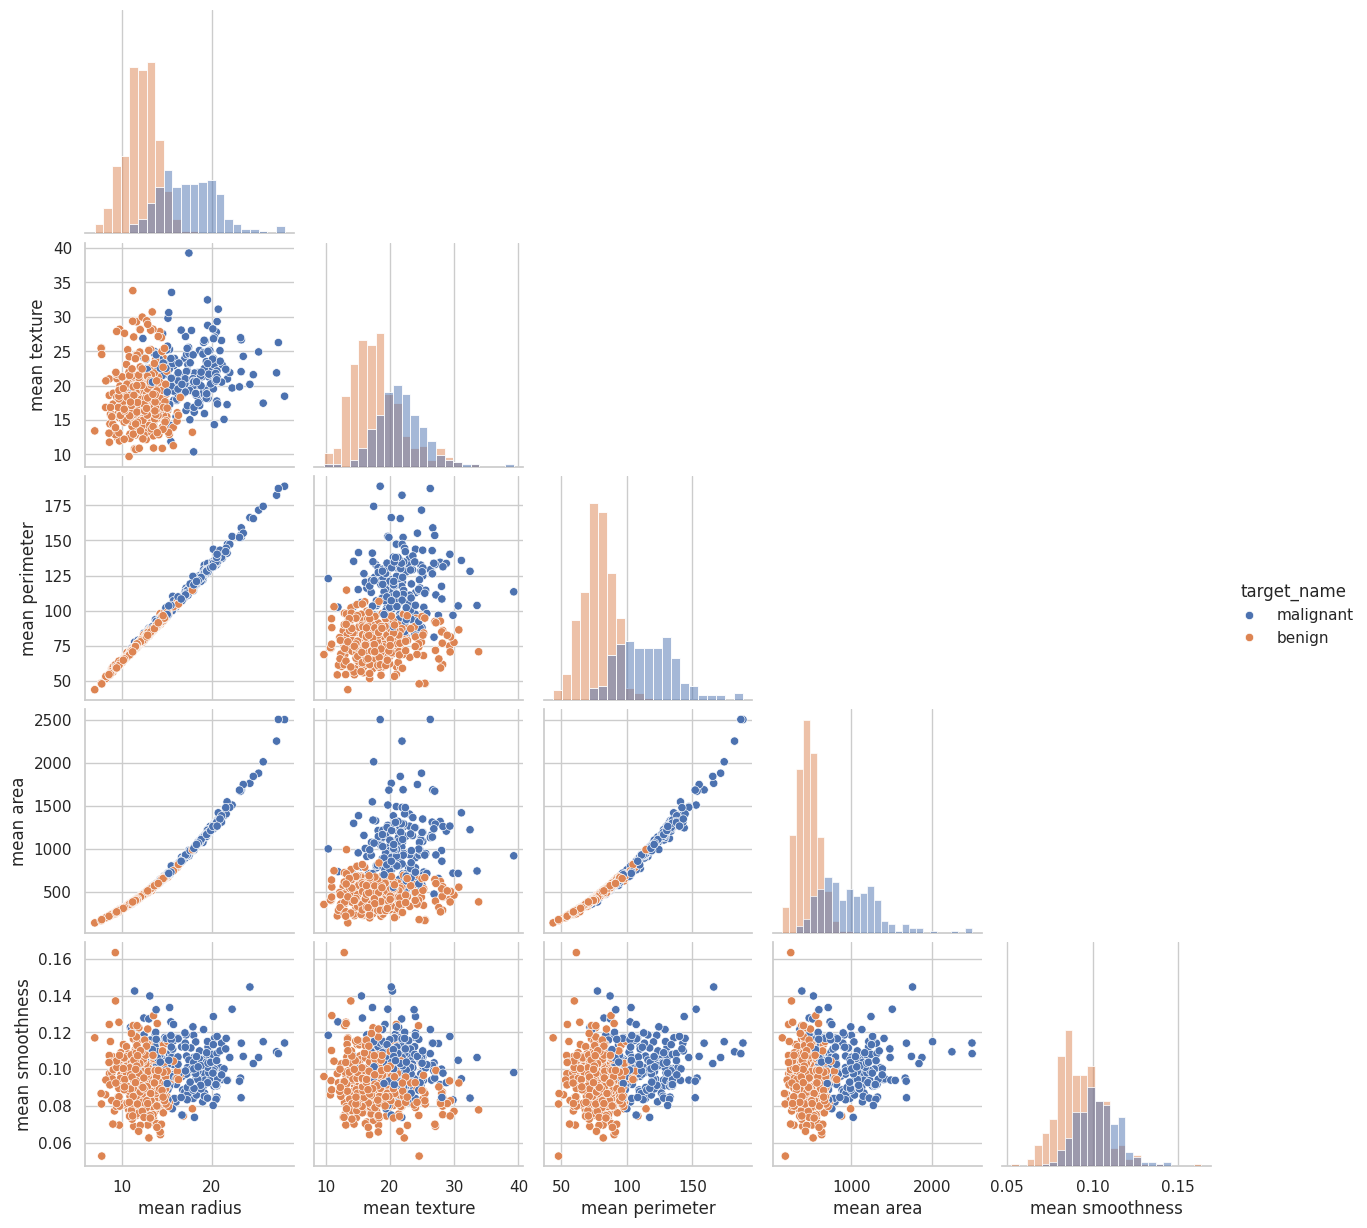

In [22]:
selected_columns = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "target_name"
]

sns.pairplot(
    df[selected_columns],
    hue="target_name",
    diag_kind="hist",
    corner=True
)
plt.show()

## Додаткова кореляційна матриця

Кореляція дозволяє оцінити зв'язки між ознаками. Значення, близькі до 1 або -1, означають сильний зв'язок.

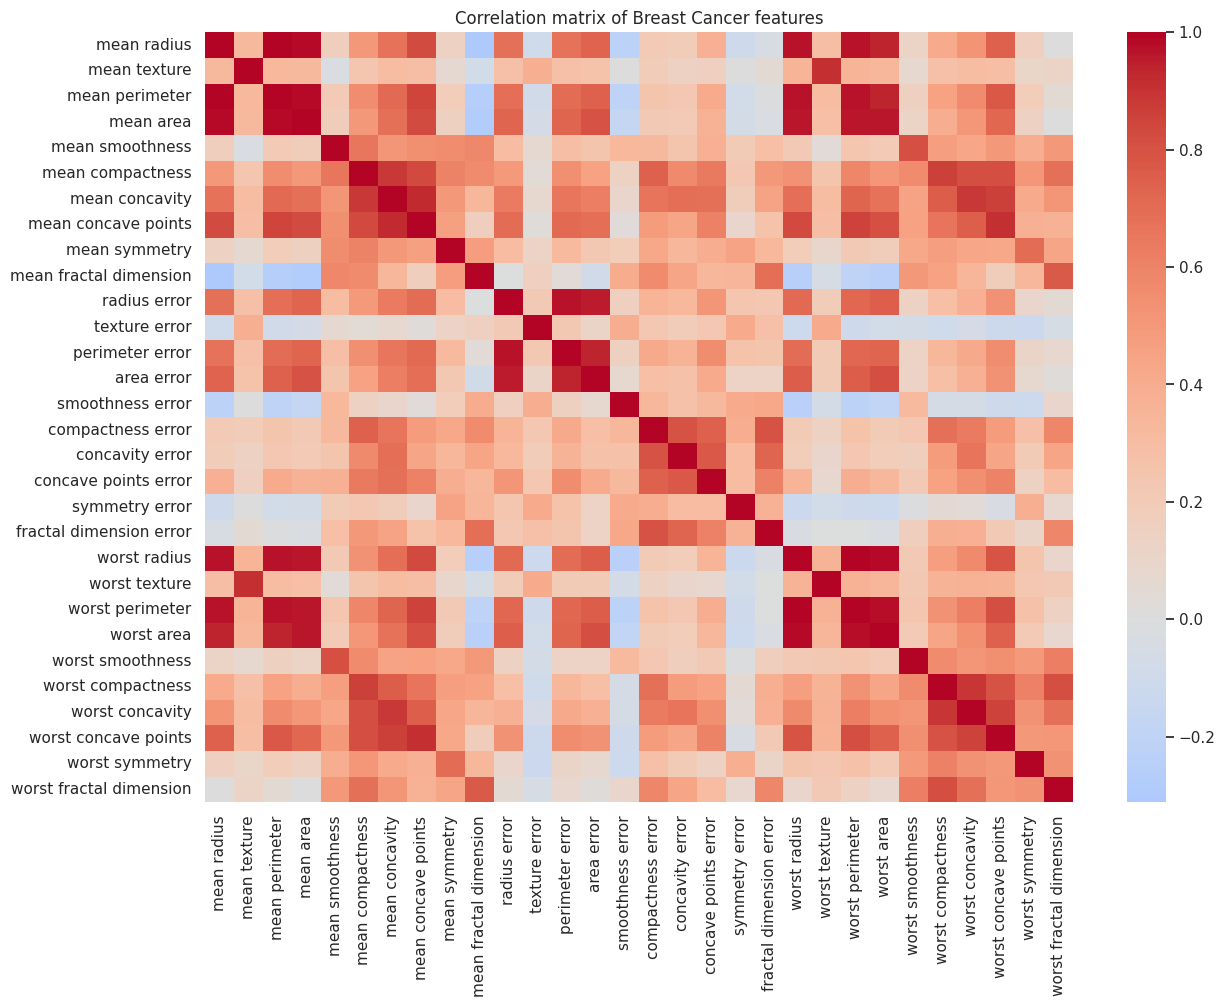

In [23]:
plt.figure(figsize=(14, 10))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation matrix of Breast Cancer features")
plt.show()

## Аналіз кореляції з цільовою змінною

Окремо переглянемо, які ознаки мають найсильніший зв'язок із класом пухлини (`target`). Це допомагає зрозуміти, які характеристики найбільше пов'язані з розділенням класів `malignant` та `benign`.

In [24]:
target_correlation = df.drop(columns=["target_name"]).corr(numeric_only=True)["target"].sort_values(ascending=False)

target_correlation

,target
target,1.000000
smoothness error,0.067016
mean fractal dimension,0.012838
texture error,0.008303
symmetry error,0.006522
fractal dimension error,-0.077972
concavity error,-0.253730
compactness error,-0.292999
worst fractal dimension,-0.323872
mean symmetry,-0.330499


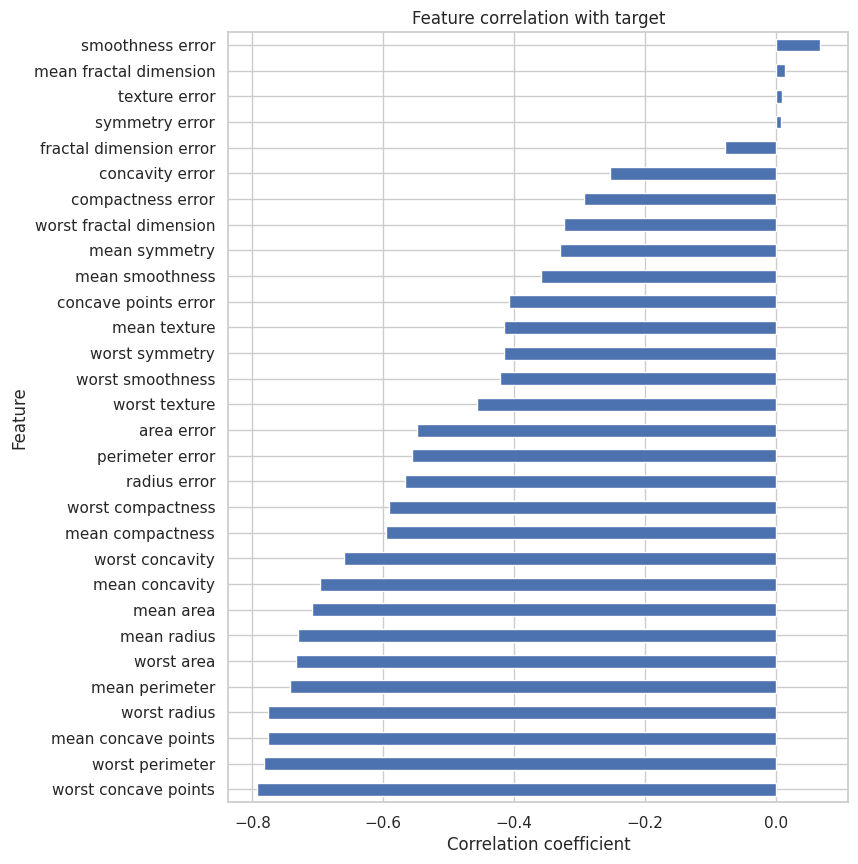

In [25]:
plt.figure(figsize=(8, 10))
target_correlation.drop("target").sort_values().plot(kind="barh")
plt.title("Feature correlation with target")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")
plt.show()

## 7. Обчислення матриць відстаней

Для повного датасету матриця відстаней має розмір 569 × 569. Її можна обчислити повністю, але для зручної візуалізації heatmap використаємо перші 50 записів після стандартизації. Такий підхід дозволяє порівняти метрики без перевантаження графіків.

Метрики:
- `euclidean` — евклідова відстань;
- `cityblock` — мангеттенська відстань;
- `manhattan` — синонім `cityblock`;
- `l1` — також еквівалент мангеттенській відстані;
- `cosine` — косинусна відстань, яка оцінює напрям векторів.


In [27]:
sample_size = 50
X_sample = df_scaled.drop(columns=["target", "target_name"]).iloc[:sample_size]

distance_matrices = {}

# Euclidean
distance_matrices["euclidean"] = cdist(
    X_sample, X_sample, metric="euclidean"
)

# Cosine
distance_matrices["cosine"] = cdist(
    X_sample, X_sample, metric="cosine"
)

# Cityblock (L1 distance)
distance_matrices["cityblock"] = cdist(
    X_sample, X_sample, metric="cityblock"
)

# Manhattan — синонім Cityblock
distance_matrices["manhattan"] = distance_matrices["cityblock"].copy()

# L1 — також синонім Manhattan
distance_matrices["l1"] = distance_matrices["cityblock"].copy()

for metric, matrix in distance_matrices.items():
    print(f"{metric}: shape = {matrix.shape}")

euclidean: shape = (50, 50)
cosine: shape = (50, 50)
cityblock: shape = (50, 50)
manhattan: shape = (50, 50)
l1: shape = (50, 50)


### Додатково: розмір повної матриці відстаней

Для всього датасету можна обчислити повну матрицю 569 × 569. Нижче показано її розмір для евклідової метрики. Для heatmap далі використовується менша вибірка, щоб графіки залишались читабельними.

In [28]:
X_full = df_scaled.drop(columns=["target", "target_name"])
full_euclidean_matrix = cdist(X_full, X_full, metric="euclidean")

full_euclidean_matrix.shape

(569, 569)

## 8. Візуалізація матриць відстаней

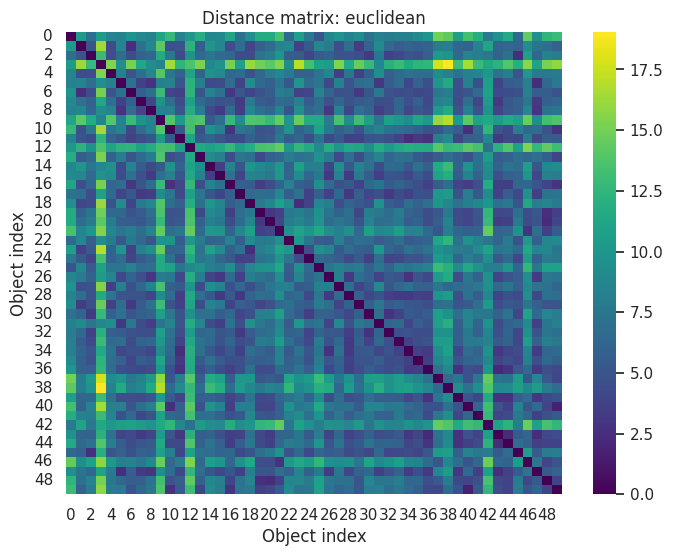

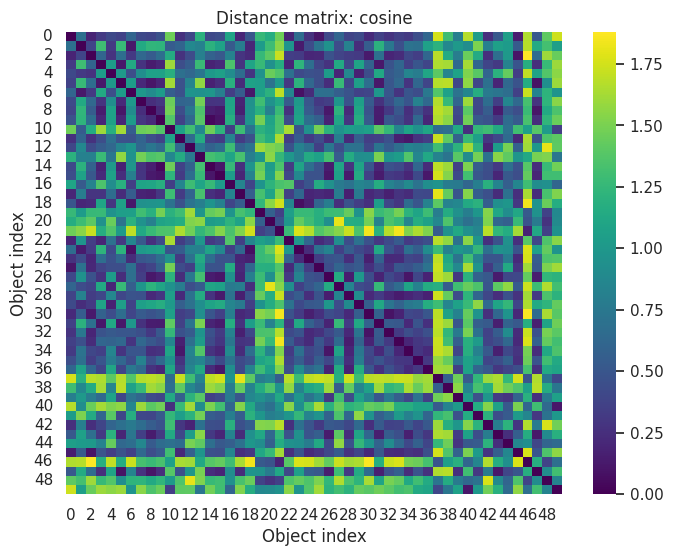

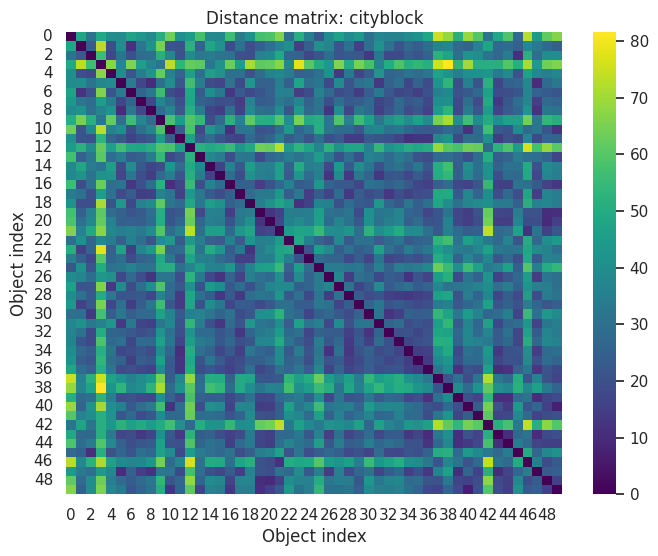

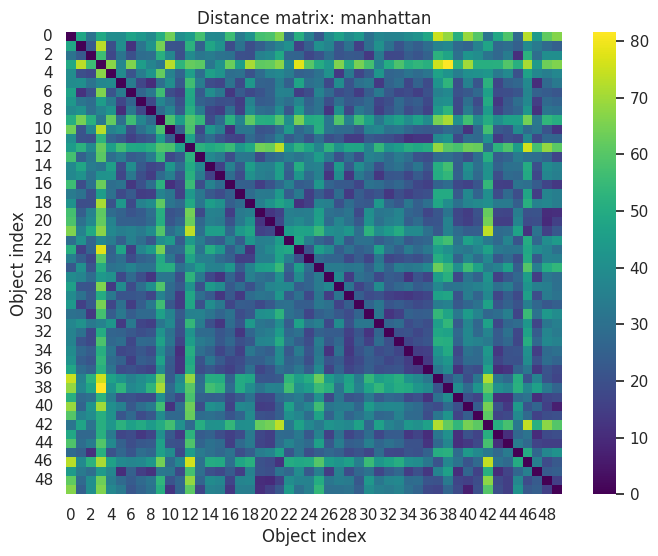

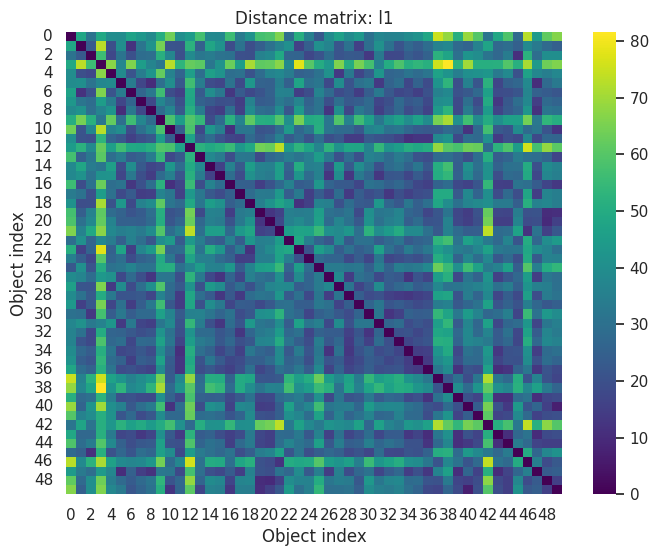

In [29]:
for metric, matrix in distance_matrices.items():
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, cmap="viridis")
    plt.title(f"Distance matrix: {metric}")
    plt.xlabel("Object index")
    plt.ylabel("Object index")
    plt.show()

## Порівняння середніх значень відстаней

In [30]:
comparison = []

for metric, matrix in distance_matrices.items():
    upper_triangle = matrix[np.triu_indices_from(matrix, k=1)]
    comparison.append({
        "metric": metric,
        "mean_distance": upper_triangle.mean(),
        "min_distance": upper_triangle.min(),
        "max_distance": upper_triangle.max(),
        "std_distance": upper_triangle.std()
    })

comparison_df = pd.DataFrame(comparison).sort_values("mean_distance")
comparison_df

,metric,mean_distance,min_distance,max_distance,std_distance
1,cosine,0.832692,0.037394,1.879311,0.467005
0,euclidean,7.305547,1.693333,19.034671,2.945135
2,cityblock,32.705778,6.867845,81.566092,13.569185
3,manhattan,32.705778,6.867845,81.566092,13.569185
4,l1,32.705778,6.867845,81.566092,13.569185


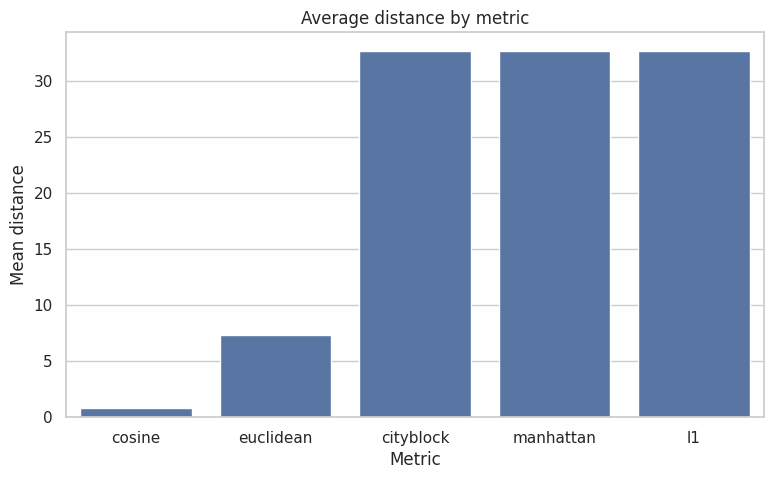

In [31]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x="metric", y="mean_distance")
plt.title("Average distance by metric")
plt.xlabel("Metric")
plt.ylabel("Mean distance")
plt.show()

## 9. Висновки

1. Набір даних Breast Cancer містить 569 об'єктів та 30 числових ознак, які описують характеристики клітинних ядер. Цільова змінна має два класи: злоякісна (`malignant`) та доброякісна (`benign`) пухлина.

2. Ознаки мають різні масштаби, тому перед обчисленням відстаней була виконана стандартизація за допомогою `StandardScaler`. Це важливо, бо без стандартизації ознаки з великими числовими значеннями, наприклад площа, могли б домінувати над іншими ознаками.

3. Для `pairplot` було використано репрезентативну підмножину ознак, оскільки повний pairplot для 30 ознак створює понад 900 графіків і є важким для аналізу. Навіть на вибраних ознаках видно, що характеристики, пов'язані з радіусом, периметром і площею, допомагають розділяти класи.

4. Кореляційна матриця показала сильний зв'язок між деякими ознаками. Зокрема, радіус, периметр і площа мають високу позитивну кореляцію між собою, що логічно, оскільки всі вони описують розмір клітинного ядра.

5. Аналіз кореляції з цільовою змінною показує, які ознаки найбільше пов'язані з класом пухлини. Це корисно для попереднього аналізу даних перед побудовою моделей машинного навчання.

6. Метрики `cityblock`, `manhattan` та `l1` дали однакові результати, оскільки всі вони відповідають L1-відстані. Тому в практичному аналізі достатньо використовувати одну з них.

7. Евклідова відстань (`euclidean`) добре підходить для стандартизованих числових даних, оскільки вимірює геометричну близькість об'єктів у багатовимірному просторі. Саме її часто використовують як базову метрику в задачах кластеризації.

8. Мангеттенська відстань (`manhattan`, `cityblock`, `l1`) може бути корисною, коли важливо враховувати сумарні абсолютні відхилення за всіма ознаками. Вона може бути менш чутливою до окремих великих відхилень, ніж евклідова метрика.

9. Косинусна відстань (`cosine`) оцінює не абсолютну різницю між значеннями, а подібність напрямків векторів. Вона може бути корисною, коли важливіше співвідношення між ознаками, а не абсолютна величина значень.

10. Для цього набору даних найбільш практичними є `euclidean` та `manhattan` / `cityblock` метрики. Евклідова метрика добре відображає загальну геометричну близькість об'єктів, а мангеттенська є хорошою альтернативою для перевірки стабільності результатів.

Загалом, вибір метрики залежить від задачі. Для кластеризації стандартизованих числових медичних даних доцільно починати з евклідової відстані, а потім порівнювати результати з мангеттенською та косинусною метриками.
